# Workshop figures (CCAI) — the ensemble epistemic signal is confidently wrong under shift

Frozen ensemble quantities only: the ensemble mean $\hat{\mu}$ and the between-member spread $\hat{\sigma}^2_e$ (sample variance across $M{=}10$ deterministic members, $1/(M{-}1)$ normalization; split unmodified). $\hat{\sigma}^2_e$ **is read as a lower bound on** the epistemic uncertainty a well-specified ensemble should express — never *is* epistemic uncertainty.

**Claim.** The model is skilled (the mean is good), yet $\hat{\sigma}^2_e$ is *confidently wrong under shift*: it stays narrow while error grows, and the failure is **flow-dependent — worst at the highest flows**. Error common to all members (*common-mode*) is invisible to a between-member spread. Aleatoric uncertainty is handled elsewhere [Klotz, Kraft]; there is **no variance head** here — members are deterministic point predictors.

Figure set: **(1)** event hydrographs — the ensemble band misses the peak (illustration); **(2)** spread under-dispersion by flow regime (standardized residuals) — the population evidence; **(3)** informativeness under shift — the signal stays *informative*, only its magnitude undershoots.

In [1]:
# Frozen ensemble grids + shared plotting style (CCAI, NeurIPS single-column)
import sys, pathlib
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr

# ---- locate project root (dir holding src/config.py), independent of kernel cwd ----
# Re-running this cell self-heals a stale kernel after the source dir moves:
# it finds the current tree and drops any cached `src.*` so the import rebinds.
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "src" / "config.py").exists()), None)
if _root is None:
    raise RuntimeError(f"project root not found from cwd={pathlib.Path.cwd()}; "
                       "launch Jupyter inside the repo (or run this cell from within it).")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
for _m in [m for m in list(sys.modules) if m == "src" or m.startswith("src.")]:
    del sys.modules[_m]
from src.config import OUTPUT_DATA_DIR
print(f"project root: {_root}")

# ============================ SIZING SYSTEM ============================
# Figures render at S x their in-paper size. In LaTeX use:
#     \includegraphics[width=\columnwidth]{fig.pdf}
# S cancels under width=..., so ONLY (aspect ratio) and (font:width ratio)
# reach the page -- both are fixed here. All widths are uniform (=FIG_W*S)
# so the three figures are visually consistent; heights are minimized.
S      = 1.8            # source-render scale ("big"); cancels at width=\columnwidth
FIG_W  = 5.5           # intended in-paper width (NeurIPS/CCAI single-column text width, in)
def figsize(ratio):    # ratio = width:height ; larger ratio => shorter (less vertical space)
    return (FIG_W*S, (FIG_W/ratio)*S)
def off(x, y):  return (x*S, y*S)     # scale offset-point annotation offsets
def sz(area):   return area*S*S       # scale scatter marker AREA (points^2) ~ linear in S

# absolute type/line sizes (pt), all x S so the font:width ratio is invariant
FS = dict(title=10*S, sub=9*S, lab=9*S, tick=8*S, leg=8*S, ann=8*S, emph=10*S)
LW = dict(thin=0.6*S, mu=1.4*S, obs=1.9*S, ref=1.7*S, curve=2.4*S)

# ---- brand-neutral, colorblind-safe (Okabe-Ito), assigned by JOB ----
PALETTE = dict(
    obs    = "#111111",   # observations / realized error (truth)
    mu     = "#8A8A8A",   # ensemble mean mu-hat (recessive reference)
    ens    = "#D55E00",   # between-member spread sigma_e (the signal under test)
    indist = "#0072B2",   # in-distribution / calibrated regime
    ref    = "#555555",   # nominal / best-possible / neutral references
    random = "#AFAFAF",   # no-skill baseline
)
mpl.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 8.5*S,
    "axes.titlesize": FS["title"], "axes.titleweight": "bold", "axes.titlepad": 6*S,
    "axes.labelsize": FS["lab"], "axes.labelpad": 3*S,
    "xtick.labelsize": FS["tick"], "ytick.labelsize": FS["tick"], "legend.fontsize": FS["leg"],
    "axes.linewidth": 0.9*S, "axes.edgecolor": "#444444",
    "axes.grid": True, "grid.color": "#666666", "grid.alpha": 0.28,
    "grid.linestyle": ":", "grid.linewidth": 0.7*S,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#444444", "ytick.color": "#444444",
    "xtick.major.size": 3*S, "ytick.major.size": 3*S,
    "xtick.major.width": 0.8*S, "ytick.major.width": 0.8*S,
    "legend.frameon": False, "mathtext.fontset": "dejavusans",
})
SIG = r"$\hat{\sigma}^2_e$"; MU = r"$\hat{\mu}$"
FIG_OUT = _root/"figures"  # exported PNGs land here, mirroring the Overleaf figures/ dir
FIG_OUT.mkdir(exist_ok=True)

# opaque legend box: panel (b)'s curves and Fig 2's whiskers run behind the legend,
# and rcParams sets frameon=False globally, so text on bare curves was unreadable
LEG = dict(frameon=True, facecolor="white", edgecolor="#CCCCCC", framealpha=.95,
           borderpad=.45, labelspacing=.35, handletextpad=.6)

def panel(ax, letter, title, **kw):
    """Chapter-style bold, left-aligned '(x) Title' panel header."""
    kw.setdefault("fontsize", FS["sub"])
    ax.set_title(f"({letter}) {title}", loc="left", fontweight="bold", **kw)

# ---- frozen quantities (mu-hat, sigma_e^2, split unmodified) ----
R = OUTPUT_DATA_DIR/"results_MVE"; VAR = R/"variance"
idx = pd.read_csv(R/"index_dates.csv", parse_dates=["date"])
dates = pd.DatetimeIndex(idx["date"]); split = idx["split"].to_numpy()
y = np.load(R/"y_obs_mm.npy")
try: valid = np.load(R/"valid_mask.npy")
except FileNotFoundError: valid = np.load(R/"valid_mask_ald.npy")
pred = np.load(VAR/"predictive.npz")
mu, sigma_e2 = pred["mu_hat"], pred["sigma_e2"]
sig_e = np.sqrt(sigma_e2)                        # between-member spread
stations = pd.read_csv(R/"q_std.csv")["station_id"].astype(str).to_numpy()
Z = 1.96

# ---- OOD illustration windows (2021 heat dome, AR flood) ----
EVENTS = {"2021 heat dome": ("2021-06-01","2021-07-31"),
          "2021 AR flood":  ("2021-10-20","2021-12-10")}
ood_date = np.zeros(len(dates), bool)
for a,b in EVENTS.values(): ood_date |= (dates>=pd.Timestamp(a)) & (dates<=pd.Timestamp(b))
test = (split=="test")
M_ind = (test & ~ood_date)[:,None] & valid      # in-distribution test cells
M_ood = (test & ood_date)[:,None] & valid       # OOD event cells (test-only by construction)
err = np.abs(y-mu); err2 = (y-mu)**2

# within-basin flow-percentile deciles (regime stratification), ranked within the TEST
# period ONLY so train/val flows never inform the binning (test-set-only figures)
pct = pd.DataFrame(np.where(test[:,None] & valid, y, np.nan)).rank(pct=True).to_numpy()
bi = np.clip(np.nan_to_num(pct)*10, 0, 9).astype(int)
tb = (test[:,None] & valid) & np.isfinite(pct)
print(f"style: source {FIG_W*S:.1f}in wide (S={S}); set width=\\columnwidth in LaTeX")
print(f"test cells {int(tb.sum()):,} | in-dist {int(M_ind.sum()):,} | OOD {int(M_ood.sum()):,}")

project root: /Users/justingallant/src/Research-2026S/EA-LSTM-Streamflow
style: source 9.9in wide (S=1.8); set width=\columnwidth in LaTeX
test cells 877,729 | in-dist 850,664 | OOD 27,065


## Figure 1 — Event hydrographs: the ensemble band misses the peak *(illustration)*
Observed runoff vs the ensemble mean $\hat{\mu}$, with the $\pm1.96\,\hat{\sigma}_e$ between-member band, for the two 2021 OOD events. The band is a sliver hugging the mean — it does not reach the observed peaks. These events *illustrate* the population result in Fig. 2; they are not the evidence base.

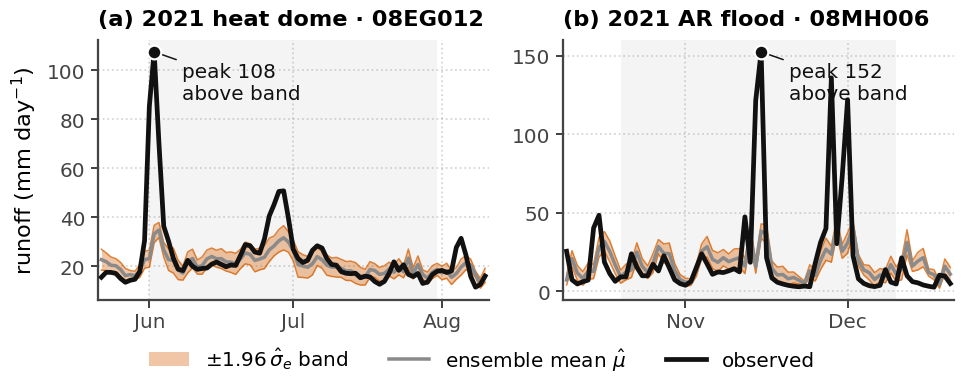

In [2]:
fig, axes = plt.subplots(1, 2, figsize=figsize(2.5))
for k,(ax,(nm,(a,b))) in enumerate(zip(axes, EVENTS.items())):
    a_ts, b_ts = pd.Timestamp(a), pd.Timestamp(b)
    w = (dates >= a_ts-pd.Timedelta(days=10)) & (dates <= b_ts+pd.Timedelta(days=10))
    wi = np.where(w)[0]; core = (dates>=a_ts)&(dates<=b_ts)
    j = int(np.nanargmax(np.nanmax(np.where(core[:,None]&valid, y, np.nan), axis=0)))
    d = dates[wi]; o = y[wi,j]; m = mu[wi,j]; sE = sig_e[wi,j]
    ax.axvspan(a_ts, b_ts, color="#000000", alpha=.045, lw=0, zorder=0)      # event window
    ax.fill_between(d, m-Z*sE, m+Z*sE, color=PALETTE["ens"], alpha=.35, lw=0, zorder=2,
                    label=r"$\pm1.96\,\hat{\sigma}_e$ band")
    ax.plot(d, m+Z*sE, color=PALETTE["ens"], lw=LW["thin"], alpha=.75, zorder=2)
    ax.plot(d, m-Z*sE, color=PALETTE["ens"], lw=LW["thin"], alpha=.75, zorder=2)
    ax.plot(d, m, color=PALETTE["mu"], lw=LW["mu"], zorder=3, label=f"ensemble mean {MU}")
    ax.plot(d, o, color=PALETTE["obs"], lw=LW["obs"], zorder=4, label="observed")
    oc = np.where(core[wi], o, np.nan); kp = int(np.nanargmax(oc))
    ax.plot(d[kp], o[kp], "o", ms=5.5*S, mfc=PALETTE["obs"], mec="white", mew=.9*S, zorder=6)
    ax.annotate(f"peak {o[kp]:.0f}\nabove band", xy=(d[kp], o[kp]),
                xytext=off(11, -4), textcoords="offset points", ha="left", va="top",
                fontsize=FS["ann"], color=PALETTE["obs"],
                arrowprops=dict(arrowstyle="-", lw=LW["thin"], color=PALETTE["obs"]))
    panel(ax, "ab"[k], f"{nm} · {stations[j]}")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.margins(x=.01)
axes[0].set_ylabel(r"runoff (mm day$^{-1}$)")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, bbox_to_anchor=(.5, -.02), fontsize=FS["leg"])
fig.tight_layout(rect=(0, .07, 1, 1)); plt.show()

**How to read it · station selection.** Each panel shows the single basin with the **largest observed peak** inside that event window, chosen automatically across all 269 basins:

```
core = (dates >= a) & (dates <= b)                                  # the event window
j = nanargmax( nanmax( where(core & valid, y, nan), axis=0 ) )      # basin with the biggest event peak
```

That gives the heat dome → **08EG012** (108 mm day⁻¹) and the AR flood → **08MH006** (152 mm day⁻¹); the plotted window is padded ±10 days so the rise and recession are visible.

- The $\pm1.96\,\hat{\sigma}_e$ band is a **sliver on $\hat{\mu}$** and never reaches the observed peak — the between-member spread does not widen where the model most under-predicts.
- This is **selection on the outcome** (the observed peak), so Fig. 1 is an **illustration, not evidence**, and not representative — the population result in Fig. 2 is the evidence base. Selecting on the *physical event magnitude* (not on model error or on $\hat{\sigma}_e$ itself) keeps it one step removed from circular, but it remains an anecdote backed by the curve, never a proof.

## Figure 1 (Overleaf) — Residual spread relative to ensemble spread

Ratio of two spread measures per within-basin flow decile, over all 269 basins across the test period (2013–2022). Each basin's valid test days are ranked into percentiles and pooled by decile.

- **Numerator — residual spread:** the standard deviation of the residuals $r=y-\hat{\mu}$ over the cells in that decile, $\mathrm{sd}(r)=\sqrt{\overline{(r-\bar{r}_k)^2}}$, in mm day$^{-1}$.
- **Denominator — ensemble spread:** the root-mean-square of the per-cell between-member spread, $\sqrt{\overline{\hat{\sigma}^2_e}}$, times the finite-ensemble factor $\sqrt{(M{+}1)/M}$ with $M{=}10$ (the contract stores $\hat{\sigma}^2_e$ as the $\mathrm{ddof}{=}1$ sample variance across members), also in mm day$^{-1}$.

Both terms are standard deviations in the same units, so the ratio is dimensionless. A calibrated ensemble sits on the dashed line at $1\times$; shading marks the gap from $1\times$ to the plotted ratio. Because the numerator is an SD, each decile's mean residual is removed *inside* the statistic — the ratio carries no bias contribution and is **exactly mean-independent**. It is the reciprocal of the conventional spread–skill ratio, plotted this way so the axis carries the factors quoted in the text.

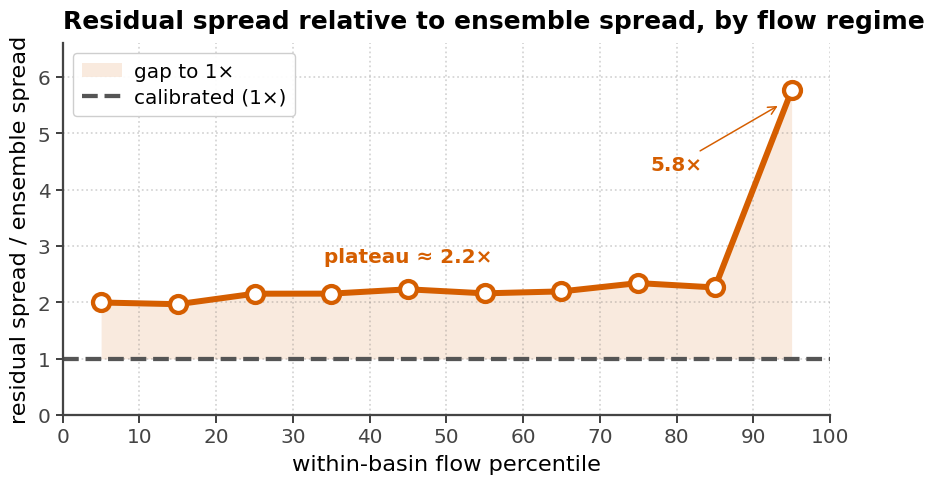

test-set only: 0 non-test cells (0 expected) | cells 877,729
M=10, finite-ensemble correction sqrt((M+1)/M)=1.0488 applied to the ddof=1 spread
decile        n   RMS sigma_e   resid SD   undersize   (ratio)
  0-10   82,317      0.1141     0.2281       2.00x    0.5001
 10-20   88,420      0.1420     0.2797       1.97x    0.5079
 20-30   90,156      0.1903     0.4102       2.16x    0.4639
 30-40   96,425      0.2376     0.5124       2.16x    0.4637
 40-50   84,593      0.3175     0.7092       2.23x    0.4477
 50-60   85,847      0.3824     0.8266       2.16x    0.4626
 60-70   86,898      0.4695     1.0311       2.20x    0.4553
 70-80   87,409      0.5657     1.3260       2.34x    0.4267
 80-90   87,734      0.7216     1.6352       2.27x    0.4413
 90-100  87,930      0.9745     5.6161       5.76x    0.1735
plateau 0-90: mean-of-deciles 2.16x | pooled 2.25x | range 1.97x-2.34x
top decile:   5.76x   |   all test pooled 4.13x


In [3]:
# Figure 1 (Overleaf): how many times too narrow the ensemble spread is, by flow decile.
# Undersize factor = residual SD / (RMS sigma_e * sqrt((M+1)/M)) -- the reciprocal spread-skill
# ratio. Mean-independent by construction: the numerator is an SD, so no mean-removal enters.
import json
M = json.loads((R/"meta.json").read_text())["n_members"]     # 10; sigma_e2 is ddof=1 per contract
CORR = np.sqrt((M+1)/M)                                      # finite-ensemble spread inflation
cc = np.arange(5,100,10); und = np.empty(10); nn = np.empty(10, int)
for k in range(10):
    m = (bi==k)&tb
    und[k] = (y-mu)[m].std() / (np.sqrt(np.mean(sigma_e2[m]))*CORR)
    nn[k] = int(m.sum())

fig, ax = plt.subplots(figsize=figsize(2.05))
ax.fill_between(cc, 1.0, und, color=PALETTE["ens"], alpha=.13, lw=0, zorder=1,
                label="gap to 1×")
ax.axhline(1.0, ls="--", lw=LW["ref"], color=PALETTE["ref"], zorder=2,
           label="calibrated (1×)")
ax.plot(cc, und, "-", color=PALETTE["ens"], lw=LW["curve"], zorder=3)
# no series label: the y-axis names the quantity and there is only one series
ax.scatter(cc, und, s=sz(46), facecolor="white", edgecolor=PALETTE["ens"], linewidths=1.7*S,
           zorder=4)
ax.set_xlabel("within-basin flow percentile")
ax.set_ylabel("residual spread / ensemble spread")
ax.set_title("Residual spread relative to ensemble spread, by flow regime", loc="left")
ax.set_xlim(0,100); ax.set_ylim(0,6.6)
ax.set_xticks(range(0,101,10)); ax.set_xticklabels(range(0,101,10))
ax.set_yticks(range(0,7))
ax.text(45, 2.72, f"plateau ≈ {und[:9].mean():.1f}×", ha="center",
        fontsize=FS["ann"], fontweight="bold", color=PALETTE["ens"], zorder=6)
ax.annotate(f"{und[9]:.1f}×", xy=(93.5, und[9]-.25), xytext=(80, 4.35),
            textcoords="data", ha="center", fontsize=FS["ann"], fontweight="bold",
            color=PALETTE["ens"], zorder=6,
            arrowprops=dict(arrowstyle="->", lw=LW["thin"], color=PALETTE["ens"]))
ax.legend(loc="upper left", **LEG).set_zorder(7)
fig.savefig(FIG_OUT/"workshop_fig1_dispersion.png"); plt.show()

print(f"test-set only: {int((tb & ~np.broadcast_to(test[:,None],tb.shape)).sum())} non-test cells "
      f"(0 expected) | cells {int(tb.sum()):,}")
print(f"M={M}, finite-ensemble correction sqrt((M+1)/M)={CORR:.4f} applied to the ddof=1 spread")
print("decile        n   RMS sigma_e   resid SD   undersize   (ratio)")
for k in range(10):
    m=(bi==k)&tb
    print(f"{k*10:3d}-{k*10+10:<3d} {nn[k]:7,d} {np.sqrt(np.mean(sigma_e2[m]))*CORR:11.4f} "
          f"{(y-mu)[m].std():10.4f} {und[k]:10.2f}x {1/und[k]:9.4f}")
m09=(bi<=8)&tb
p09=(y-mu)[m09].std()/(np.sqrt(np.mean(sigma_e2[m09]))*CORR)
pall=(y-mu)[tb].std()/(np.sqrt(np.mean(sigma_e2[tb]))*CORR)
print(f"plateau 0-90: mean-of-deciles {und[:9].mean():.2f}x | pooled {p09:.2f}x | "
      f"range {und[:9].min():.2f}x-{und[:9].max():.2f}x")
print(f"top decile:   {und[9]:.2f}x   |   all test pooled {pall:.2f}x")

**Discussion.** The factor is **flat across the normal flow range** — every decile from 0 to 90% sits at **$\approx2.2\times$ too narrow** (mean of decile factors $2.16\times$; pooled $2.25\times$; per-decile range $1.97$–$2.34\times$). Then it spikes at the highest flows to **$5.76\times$**. Two regimes, one number each. The plateau is genuinely flat rather than drifting — a claim the earlier standardized-residual basis could not support, because its per-decile offset varied and manufactured structure of its own.

Since $\hat{\sigma}_e$ is the spread *between* members, it registers only their disagreement. The members share architecture, data, and forcing, differing only in initialization and SGD noise, so error built into that shared setup is **common-mode**: every member commits it together, agreement stays high, and the spread cannot widen to express it. The under-dispersion measured here is that over-agreement.

$\hat{\sigma}^2_e$ is read as a **lower bound** on the epistemic uncertainty a well-specified ensemble should express; this figure says the bound falls short by roughly a factor of two everywhere and by nearly six at the extreme. Aleatoric uncertainty is handled elsewhere [Klotz, Kraft] — there is no variance head here.

*Caveats.* Cells are pooled across basins and days, so $n$ per decile ($\approx$ 82k–96k) far overstates the effective sample size under spatial and temporal autocorrelation; no CI is placed on these factors and none should be read into small decile-to-decile differences. The factor is a second-moment statement and says nothing about distributional shape — the retained boxplot supplement below covers that.

### Supplement (not the CCAI figure) — standardized-residual distribution

Retained for the HESS distributional supplement and for the per-decile exceedance numbers it prints. **Not exported and not used as the CCAI figure:** its basis $z=(y-\hat{\mu}-\overline{r}_k)/\hat{\sigma}_e$ subtracts each decile's *pooled* mean residual in mm day$^{-1}$ and then divides by a *per-cell* $\hat{\sigma}_e$ that varies by orders of magnitude. That ordering injects an offset of $|\overline{r}_k|/\hat{\sigma}_e$ per cell — which ranges from 0.30 to 2.75 across deciles, driving the apparent 80–90% dip — and at the top decile it inverts the asymmetry, halving the genuine positive tail ($q_{97.5}$ from $+19.2$ to $+10.6$) while manufacturing a $-42.7$ negative one. The spread–skill ratio above avoids all of this by never removing a mean.

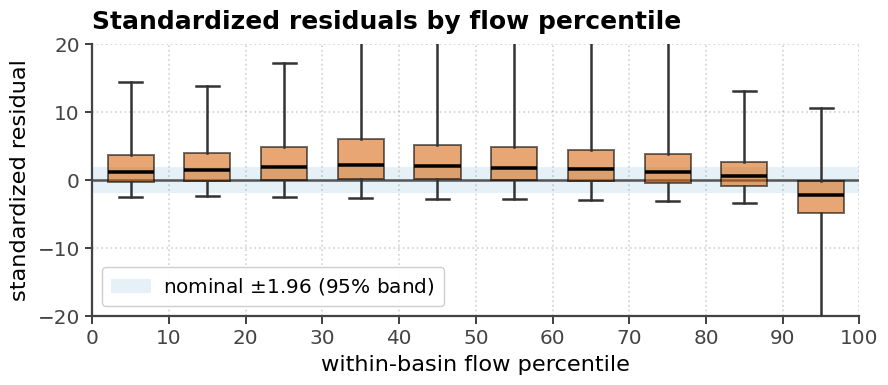

decile        n     q2.5   q97.5   % |z|>1.96
  0-10    82,317    -2.50   14.35       44.8
 10-20    88,420    -2.35   13.79       47.7
 20-30    90,156    -2.47   17.18       53.1
 30-40    96,425    -2.65   20.62       57.8
 40-50    84,593    -2.83   23.46       56.0
 50-60    85,847    -2.81   24.75       53.8
 60-70    86,898    -2.99   23.77       51.6
 70-80    87,409    -3.12   21.15       48.3
 80-90    87,734    -3.36   13.08       40.6
 90-100   87,930   -42.66   10.61       64.9
pooled: 52.0% of |z| exceeds 1.96 (nominal 5%)
y-axis clipped at +/-20; whisker extremes span -42.7 to 24.8


In [4]:
# SUPPLEMENT (not exported, not the CCAI figure): standardized-residual distribution by
# flow decile. Basis is confounded -- see the note above -- kept for the HESS distributional
# supplement and for the per-decile exceedance numbers it prints.
cc=np.arange(5,100,10); zlist=[]
for k in range(10):
    m=(bi==k)&tb; rk=(y-mu)[m]; sk=sig_e[m]; ok=sk>1e-6
    zlist.append((rk-rk.mean())[ok]/sk[ok])      # z = (y-mu)/sigma_e, per-decile mean removed
YL=20                                            # spans every upper whisker; top decile's lower one (-42.7) is cut
fig,ax=plt.subplots(figsize=figsize(2.8))
ax.axhspan(-Z,Z,color=PALETTE["indist"],alpha=.10,lw=0,zorder=0,label=r"nominal $\pm1.96$ (95% band)")
ax.axhline(0,color=PALETTE["ref"],lw=1.0*S,zorder=1)
bp=ax.boxplot(zlist,positions=cc,widths=6,whis=[2.5,97.5],showfliers=False,patch_artist=True,zorder=3)
for box in bp["boxes"]: box.set(facecolor=PALETTE["ens"],alpha=.55,edgecolor="black",linewidth=.8*S)
for med in bp["medians"]: med.set(color="black",linewidth=1.4*S)
for el in bp["whiskers"]+bp["caps"]: el.set(color="#333333",linewidth=1.0*S)
ax.set_xlabel("within-basin flow percentile")
ax.set_ylabel("standardized residual")
ax.set_title("Standardized residuals by flow percentile",loc="left")
ax.set_xlim(0,100); ax.set_ylim(-YL,YL)
# both calls are needed: boxplot leaves a FixedFormatter that mislabels the new tick positions
ax.set_xticks(range(0,101,10)); ax.set_xticklabels(range(0,101,10))
ax.legend(loc="lower left",**LEG).set_zorder(7)
plt.show()

# numbers behind the boxes (the y-axis is clipped, so read the whisker positions here)
q=np.array([[np.percentile(z,2.5),np.percentile(z,97.5)] for z in zlist])
print("decile        n     q2.5   q97.5   % |z|>1.96")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<3d} {zlist[k].size:8,d} {q[k,0]:8.2f} {q[k,1]:7.2f} {100*np.mean(np.abs(zlist[k])>Z):10.1f}")
zall=np.concatenate(zlist)
print(f"pooled: {100*np.mean(np.abs(zall)>Z):.1f}% of |z| exceeds 1.96 (nominal 5%)")
print(f"y-axis clipped at +/-{YL}; whisker extremes span {q.min():.1f} to {q.max():.1f}")

## Figure 2 (Overleaf) — Error after removal, 2021 OOD windows

Cells inside the two 2021 event windows (heat dome 06-01–07-31, AR flood 10-20–12-10; both fall inside the test split; $n=27{,}065$) are discarded largest-first under three removal rules, and the RMSE of whatever remains is plotted against the fraction discarded.

Discarding **by ensemble spread** is the rule under test. The other two bracket it: discarding **by actual error** removes the genuinely worst predictions first and is the best any rule could do — computable only after the fact; discarding **at random** is what a rule carrying no information achieves (mean of 10 permutations). **AUSE** places the spread-ranked curve between those bounds: $0$ means discarding by spread is as effective as discarding by actual error, $1$ means no better than random. Shading marks the gap between the spread-ranked and actual-error curves. The diagnostic is known as sparsification in the UQ literature.

This asks only whether $\hat{\sigma}^2_e$ carries information about *which* predictions are poor — it is not a proposal to use the spread that way. No interval is reported: see the discussion.

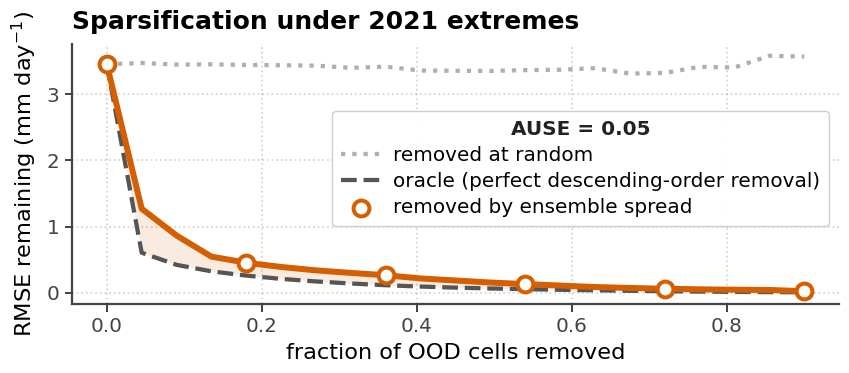

OOD cells 27,065 | in-dist cells 850,664
normalized AUSE 0.045 (0 = as good as removing by actual error, 1 = no better than random)
rank corr rho(sigma_e^2,|err|): in-dist +0.771 | OOD +0.830   (descriptive; no interval reported)


In [5]:
# Figure 2 (Overleaf): error after removal on the 2021 OOD windows (sparsification).
# Diagnostic only -- asks whether sigma_e^2 carries information about WHICH predictions are
# poor. No CI: the claim is that the spread orders error, not that two orderings differ, and
# under autocorrelation an i.i.d. interval here would be anti-conservative for no benefit.
def sparsify(se, e2, nf=21, seed=0):
    n=len(e2); fr=np.linspace(0,0.9,nf); op=np.argsort(-se); oo=np.argsort(-e2); rng=np.random.default_rng(seed)
    curve=lambda order: np.array([np.sqrt(np.mean(e2[order[int(f*n):]])) for f in fr])
    cp,co_=curve(op),curve(oo); cr=np.mean([curve(rng.permutation(n)) for _ in range(10)],axis=0)
    num=np.trapezoid(cp-co_,fr); den=np.trapezoid(cr-co_,fr)
    return fr,cp,co_,cr,(num/den if den>0 else np.nan)

se_i,e_i = sigma_e2[M_ind], err[M_ind]
se_o,e_o,e2_o = sigma_e2[M_ood], err[M_ood], err2[M_ood]
fr,cp,co_,cr,an = sparsify(se_o,e2_o)

fig, ax = plt.subplots(figsize=figsize(2.93))
ax.fill_between(fr,co_,cp,color=PALETTE["ens"],alpha=.12,lw=0,zorder=1)
ax.plot(fr,cr,":",color=PALETTE["random"],lw=LW["ref"],label="removed at random",zorder=2)
ax.plot(fr,co_,"--",color=PALETTE["ref"],lw=LW["ref"],label="oracle (perfect descending-order removal)",zorder=3)
ax.plot(fr,cp,"-",color=PALETTE["ens"],lw=LW["curve"],zorder=4)
ax.scatter(fr[::4],cp[::4],s=sz(40),facecolor="white",edgecolor=PALETTE["ens"],
           linewidths=1.6*S,zorder=5,label="removed by ensemble spread")
ax.set_xlabel("fraction of OOD cells removed")
ax.set_ylabel(r"RMSE remaining (mm day$^{-1}$)")
ax.set_title("Sparsification under 2021 extremes", loc="left")
_leg=ax.legend(loc="center right", bbox_to_anchor=(1.0,.52), title=f"AUSE = {an:.2f}", **LEG)
_leg.get_title().set(fontweight="bold", fontsize=FS["ann"], color="#222222"); _leg.set_zorder(7)
fig.savefig(FIG_OUT/"workshop_fig2_shift.png"); plt.show()

print(f"OOD cells {len(e2_o):,} | in-dist cells {len(e_i):,}")
print(f"normalized AUSE {an:.3f} (0 = as good as removing by actual error, 1 = no better than random)")
print(f"rank corr rho(sigma_e^2,|err|): in-dist {spearmanr(se_i,e_i).statistic:+.3f} | "
      f"OOD {spearmanr(se_o,e_o).statistic:+.3f}   (descriptive; no interval reported)")

**Discussion.** Fig. 1 establishes that the spread is too narrow — by $\approx2.2\times$ across normal flows and $5.76\times$ at the extreme. This figure asks a separate question: under shift, does $\hat{\sigma}^2_e$ still indicate *where* the error is large? That distinguishes **confidently wrong** (orders error correctly, magnitude far too small) from **decoupled** (spread unrelated to error). The two properties are orthogonal — a signal can rank error perfectly and still be uniformly too small, and so be overconfident everywhere.

The spread-ranked curve stays close to the actual-error curve and far from random removal (**AUSE $=0.05$**), so inside the OOD windows the spread does identify which predictions are worst. The rank correlation between $\hat{\sigma}^2_e$ and $|y-\hat{\mu}|$ is $0.77$ outside the event windows and $0.83$ inside them, in the same direction. What fails under shift is the **magnitude, not the ordering** — which is what makes the Fig. 1 result *confidently wrong* rather than uninformative, and forecloses reading the spread as noise at the events.

The claim is **diagnostic**. Nothing here recommends $\hat{\sigma}_e$ as an operational triage signal; establishing that would require a decision-analytic evaluation this paper does not attempt.

*Caveats.* **No interval is placed on AUSE or on the rank correlations, deliberately.** Cells are pooled across basins and days, so under spatial and temporal autocorrelation the effective sample size is far below the cell count and an i.i.d. resampling interval would be anti-conservative. The claim here is that the spread orders error at all, not that two orderings differ by a specific amount, so the point estimates carry it and an interval would add unwarranted precision. The actual-error curve is a post-hoc bound, not an attainable baseline. The windows pool the heat dome with the AR flood, whose ~70 stations form a spatially-blocked SW-BC corridor — see the station-constraint note in `chapter3.md` (2026-07-13).

### Flow-composition control for Figure 2 (reproduces the caveat numbers)

Both $\hat{\sigma}_e$ and $|y-\hat{\mu}|$ grow with flow magnitude, so pooling deciles gives the ordering an across-regime signal that is not discrimination *within* a regime. Recomputing AUSE separately inside each within-basin flow decile of the OOD cells holds that composition fixed. Reported, not plotted — the within-stratum reference curves differ from the pooled ones, so the two cannot share a panel honestly.

In [6]:
# Flow-composition control: AUSE within each flow decile of the OOD cells.
# Reuses sparsify() from the Figure 2 cell; seeded, so the numbers are reproducible.
per=np.full(10,np.nan); ns=np.zeros(10,int)
for k in range(10):
    m=M_ood&(bi==k); ns[k]=int(m.sum())
    if ns[k]>=200: per[k]=sparsify(sigma_e2[m], err2[m])[4]
pooled=sparsify(sigma_e2[M_ood], err2[M_ood])[4]
print("decile      n    AUSE")
for k in range(10): print(f"{k*10:3d}-{k*10+10:<3d} {ns[k]:7,d} {per[k]:7.3f}")
print(f"\npooled (unstratified)          {pooled:.3f}")
print(f"within-decile, n-weighted      {np.average(per,weights=ns):.3f}   <- quoted in the paper")
print(f"within-decile, unweighted      {np.nanmean(per):.3f}")
print(f"top three deciles (70-100%)    {per[7:].min():.3f}-{per[7:].max():.3f}   <- quoted in the paper")
print(f"random ordering would give     1.000")

decile      n    AUSE
  0-10      946   0.103
 10-20    1,826   0.086
 20-30    2,058   0.081
 30-40    3,071   0.060
 40-50    3,348   0.100
 50-60    2,643   0.077
 60-70    2,763   0.100
 70-80    3,101   0.161
 80-90    3,118   0.226
 90-100   4,191   0.165

pooled (unstratified)          0.045
within-decile, n-weighted      0.123   <- quoted in the paper
within-decile, unweighted      0.116
top three deciles (70-100%)    0.161-0.226   <- quoted in the paper
random ordering would give     1.000
